In [1]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#
# 5.1 - SHAP BeeSwarm Global Summary Plot
# 

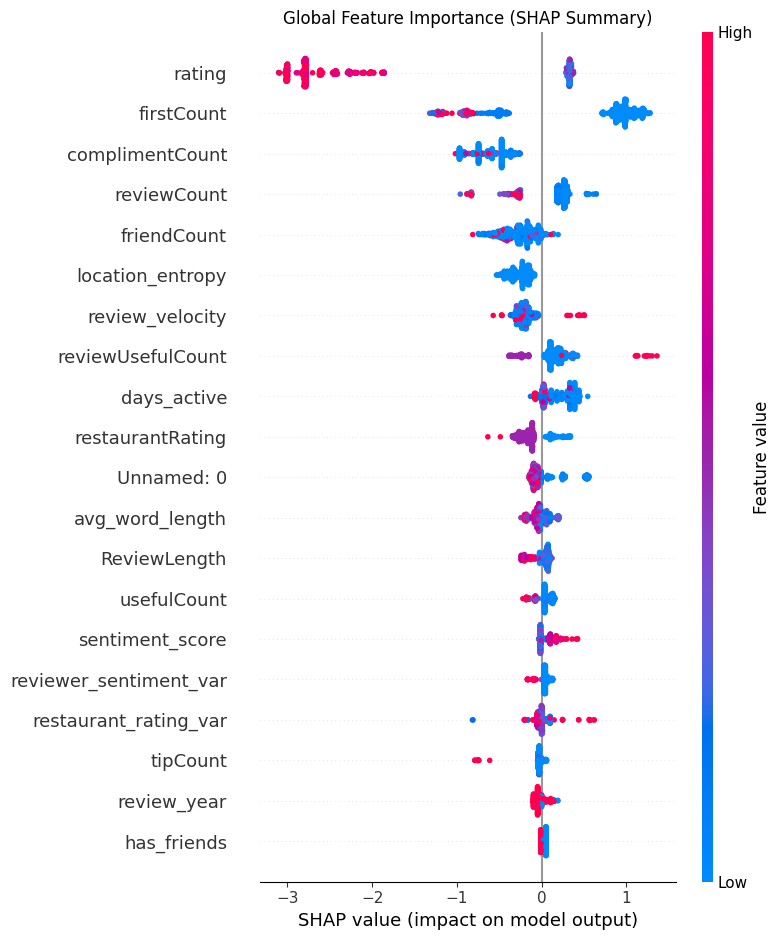

In [2]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# load model and data
model = joblib.load('../models/final_gradient_boost_model.pkl')
X_test = pd.read_csv('../data/X_test_scaled.csv')

# initialize tree explainer for gradient boosting
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# global explanation summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Global Feature Importance (SHAP Summary)")
plt.tight_layout()
plt.savefig("../images-recordings/figures/shap_feature_importance.png")
plt.show()



#
# 5.2 - SHAP Waterfall Plot
#

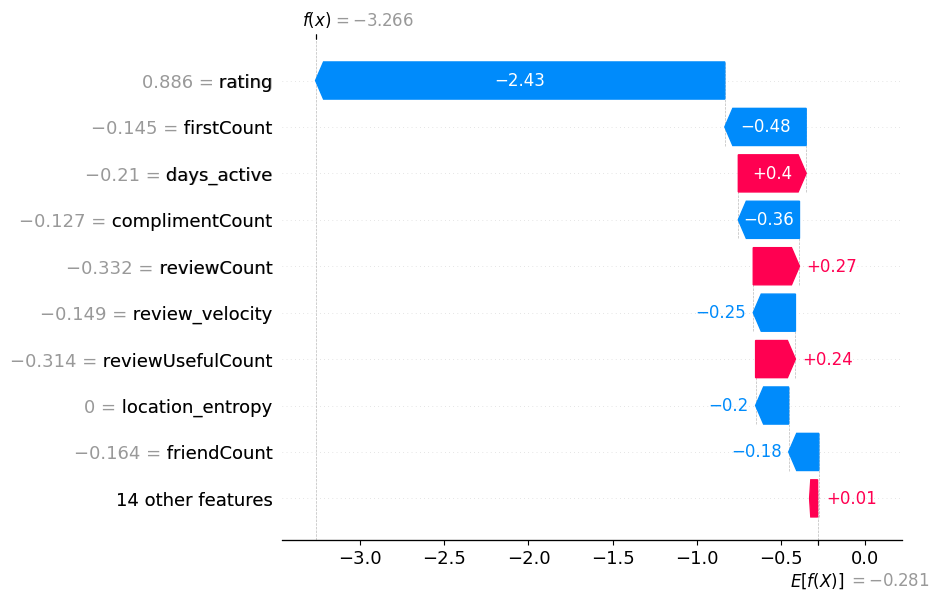

In [6]:
import matplotlib.pyplot as plt

# 1. Create a fresh canvas BEFORE SHAP does anything
fig = plt.figure()

# 2. Tell SHAP to draw on it
shap.plots.waterfall(shap_values[0], show=False)

# 3. Save the exact canvas we created in step 1
fig.savefig("../images-recordings/figures/shap_importance_scores.png", bbox_inches='tight')

# 4. Display it
plt.show()